In [ ]:
#Kütüphanelerin İçe Aktarılması
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Dosya Yolunun Tanımlanması
file_path = r'/content/drive/MyDrive/dataset.csv'

#Verinin Yüklenmesi ve Önizleme
df = pd.read_csv(file_path)

print(df.head()) #Veri setinin ilk 5 satırını gösterdik.
#Hata Yönetimi
try:
    df = pd.read_csv(file_path)
    print("Veri seti başarıyla yüklendi.")
    print(f"Toplam {df.shape[0]} satır ve {df.shape[1]} sütun bulunmaktadır.")
except FileNotFoundError:
    print(f"HATA: '{file_path}' adında bir dosya bulunamadı.")
    print("Lütfen dosya adını ve yolunu kontrol edin.")

   Year LocationAbbr      LocationDesc GeographicLevel DataSource  \
0  2020           AK            Denali          County       NVSS   
1  2020           CA        California           State       NVSS   
2  2020           CO       Park County          County       NVSS   
3  2020           FL     Walton County          County       NVSS   
4  2020           GA  Whitfield County          County       NVSS   

                     Class                    Topic  Data_Value  \
0  Cardiovascular Diseases  Heart Disease Mortality       348.8   
1  Cardiovascular Diseases  Heart Disease Mortality       230.1   
2  Cardiovascular Diseases  Heart Disease Mortality       135.9   
3  Cardiovascular Diseases  Heart Disease Mortality       126.5   
4  Cardiovascular Diseases  Heart Disease Mortality       155.1   

          Data_Value_Unit                                    Data_Value_Type  \
0  per 100,000 population  Age-adjusted, Spatially Smoothed, 3-year Avera...   
1  per 100,000 populat

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
#Projemiz ilçe bazlı bir analiz olduğu için, sadece ilçelere ait satırları aldık.
df_clean = df[df['GeographicLevel'] == 'County'].copy()
print(f"Sadece ilçe (County) verisi seçildi. Satır sayısı: {df_clean.shape[0]}")

#Gereksiz Sütunların Temizlenmesi
cols_to_drop = [
    'Year', 'DataSource', 'Class', 'Topic', 'GeographicLevel',
    'Data_Value_Type', 'Data_Value_Unit', 'Data_Value_Footnote_Symbol',
    'Data_Value_Footnote', 'StratificationCategory1', 'StratificationCategory2',
    'TopicID', 'ClassID', 'TopicType',
    'LocationDesc'
]

existing_cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_cols_to_drop)

#Sütunların Yeniden Adlandırılması
df_clean = df_clean.rename(columns={
    'LocationAbbr': 'State',
    'LocationID': 'FIPS',
    'Data_Value': 'Mortality_Rate',
    'Stratification1': 'Gender',
    'Stratification2': 'Race_Ethnicity'
})

print("Gereksiz sütunlar atıldı ve sütunlar yeniden adlandırıldı.")
df_clean.head()

Sadece ilçe (County) verisi seçildi. Satır sayısı: 77424
Gereksiz sütunlar atıldı ve sütunlar yeniden adlandırıldı.


,State,Mortality_Rate,Gender,Race_Ethnicity,FIPS,Y_lat,X_lon,Georeference
0,AK,348.8,Male,White,2068,63.678820,-149.960801,POINT (-149.9608012 63.67881971)
2,CO,135.9,Female,White,8093,39.115616,-105.708698,POINT (-105.7086982 39.11561621)
3,FL,126.5,Female,Asian,12131,30.655966,-86.157457,POINT (-86.15745736 30.65596581)
4,GA,155.1,Female,Hispanic,13313,34.803854,-84.962112,POINT (-84.96211184 34.80385386)
5,GA,NaN,Female,Asian,13299,31.051889,-82.420394,POINT (-82.4203935 31.05188914)


In [ ]:
print("\nEksik Veri Kontrolü (Temizlemeden Önce):")
print(df_clean.isnull().sum())

#Hedef Değişkeni Boş Olan Satırları Silme
df_clean.dropna(subset=['Mortality_Rate'], inplace=True)
print(f"\n'Mortality_Rate' sütununda eksik olan satırlar silindi. Yeni satır sayısı: {df_clean.shape[0]}")


print("\nVeri Tipi Kontrolü:")
df_clean.info()

if df_clean['Mortality_Rate'].dtype == 'object':
    df_clean['Mortality_Rate'] = pd.to_numeric(df_clean['Mortality_Rate'], errors='coerce')
    df_clean.dropna(subset=['Mortality_Rate'], inplace=True)


Eksik Veri Kontrolü (Temizlemeden Önce):
State                 0
Mortality_Rate    43993
Gender                0
Race_Ethnicity        0
FIPS                  0
Y_lat                 0
X_lon                 0
Georeference          0
dtype: int64

'Mortality_Rate' sütununda eksik olan satırlar silindi. Yeni satır sayısı: 33431

Veri Tipi Kontrolü:
<class 'pandas.core.frame.DataFrame'>
Index: 33431 entries, 0 to 78790
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           33431 non-null  object 
 1   Mortality_Rate  33431 non-null  float64
 2   Gender          33431 non-null  object 
 3   Race_Ethnicity  33431 non-null  object 
 4   FIPS            33431 non-null  int64  
 5   Y_lat           33431 non-null  float64
 6   X_lon           33431 non-null  float64
 7   Georeference    33431 non-null  object 
dtypes: float64(3), int64(1), object(4)
memory usage: 2.3+ MB


In [ ]:
#FIPS kodu matematiksel bir sayı değil, bir Kimlik Numarasıdır.
# Bu satırla Python'a "Bunu sayı olarak görme, metin olarak gör" diyoruz.
df_clean['FIPS'] = df_clean['FIPS'].astype(str)

#Sorunsuz birleştirme için metni 5 karaktere tamamladık.
df_clean['FIPS'] = df_clean['FIPS'].str.zfill(5)

print("\nFIPS kodları 5 haneli metin formatına dönüştürüldü (örn: '01001').")
print(df_clean[['State', 'FIPS', 'Gender', 'Race_Ethnicity']].head())


FIPS kodları 5 haneli metin formatına dönüştürüldü (örn: '01001').
  State   FIPS   Gender Race_Ethnicity
0    AK  02068     Male          White
2    CO  08093   Female          White
3    FL  12131   Female          Asian
4    GA  13313   Female       Hispanic
6    IA  19093  Overall       Hispanic


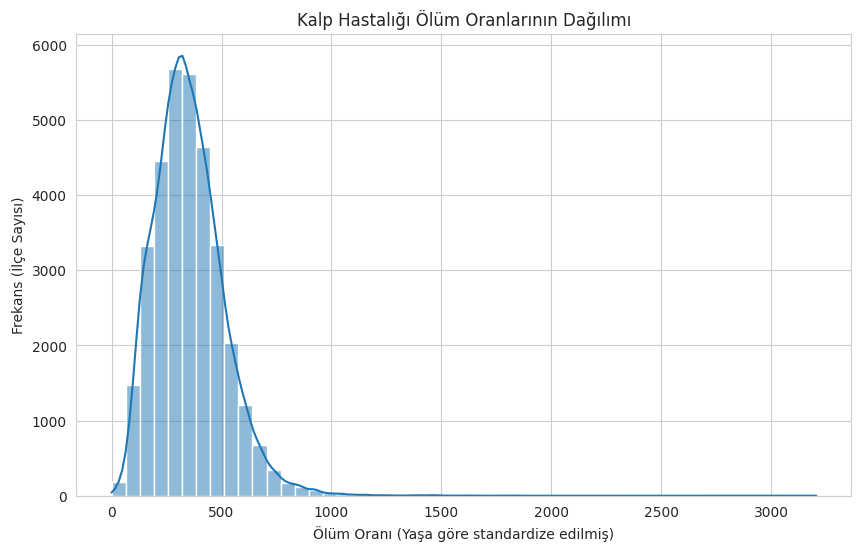

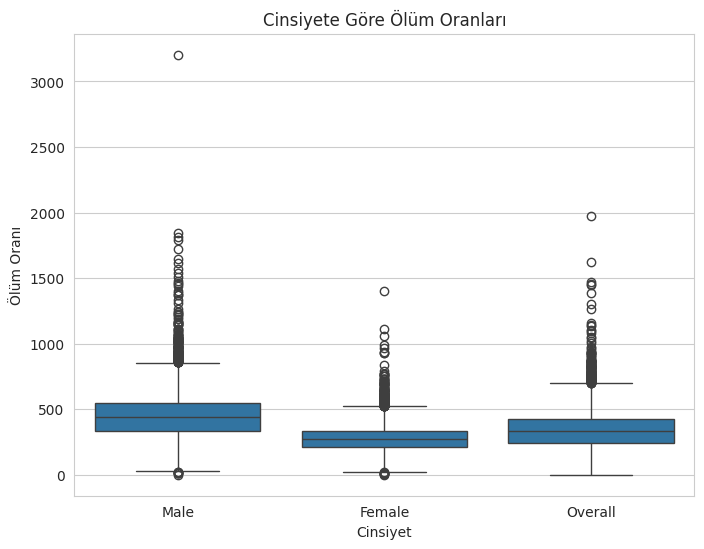

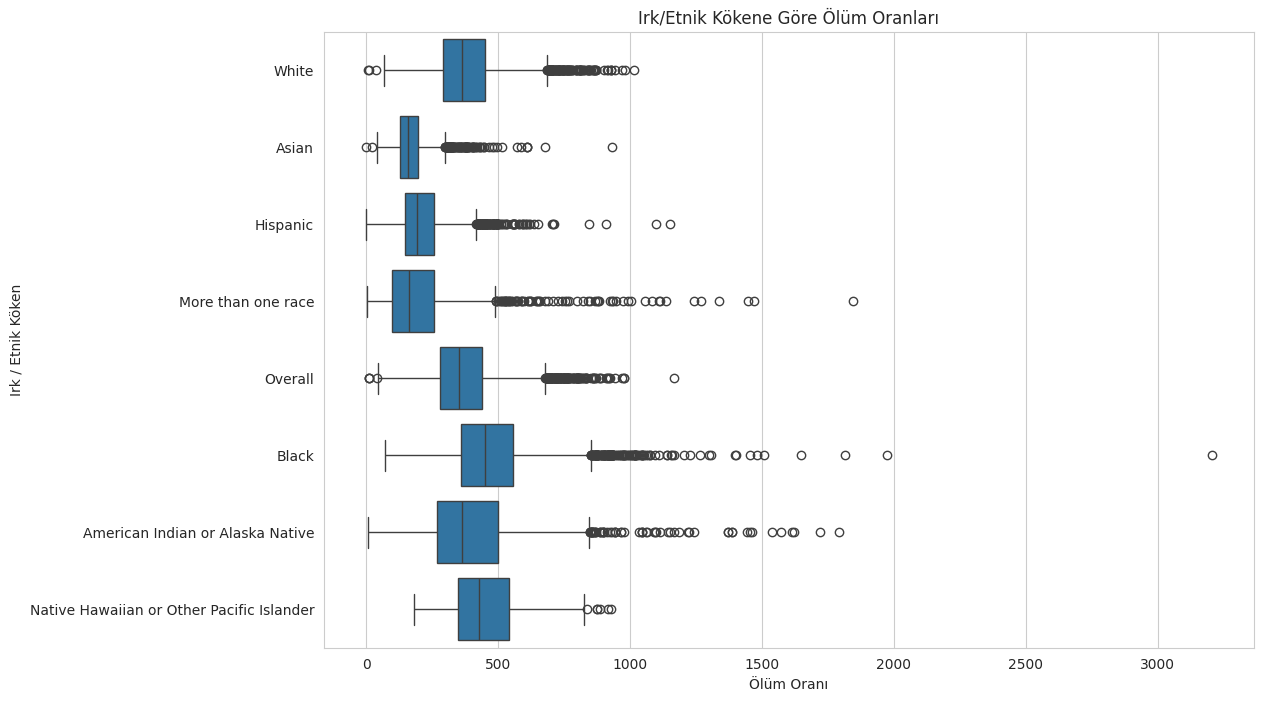

In [ ]:
sns.set_style("whitegrid")

# 1. Hedef Değişkenin (Mortality_Rate) Dağılımı
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Mortality_Rate'], kde=True, bins=50)
plt.title('Kalp Hastalığı Ölüm Oranlarının Dağılımı')
plt.xlabel('Ölüm Oranı (Yaşa göre standardize edilmiş)')
plt.ylabel('Frekans (İlçe Sayısı)')
plt.show()

# 2. Cinsiyete Göre Ölüm Oranları
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='Gender', y='Mortality_Rate')
plt.title('Cinsiyete Göre Ölüm Oranları')
plt.xlabel('Cinsiyet')
plt.ylabel('Ölüm Oranı')
plt.show()

# 3. Etnik Köken/Irka Göre Ölüm Oranları
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_clean, y='Race_Ethnicity', x='Mortality_Rate', orient='h')
plt.title('Irk/Etnik Kökene Göre Ölüm Oranları')
plt.xlabel('Ölüm Oranı')
plt.ylabel('Irk / Etnik Köken')
plt.show()

In [ ]:
#Birleştirme (merge) kodunu yazmadan önce, verinin haritasını çıkarıp inceliyoruz.
import pandas as pd
import sys
import openpyxl

files_to_check = [r"/content/drive/MyDrive/Poverty2023.xlsx",r"/content/drive/MyDrive/Education2023.xlsx", r"/content/drive/MyDrive/Unemployment2023.xlsx"]


for file in files_to_check:
    try:
        xls = pd.ExcelFile(file)

        sheet_names = xls.sheet_names
        print(f"Bulunan Sekme Adları: {sheet_names}")

        data_sheet_name = None
        for name in sheet_names:
            if "description" not in name.lower() and "readme" not in name.lower():
                data_sheet_name = name
                print(f"Veri sekmesi olarak '{data_sheet_name}' seçildi.")
                break

        if not data_sheet_name:
            print("Veri sekmesi bulunamadı.")
            continue

        print(f"\n'{data_sheet_name}' sekmesinin ilk 10 satırı (HAM GÖRÜNÜM):")
        df_preview = pd.read_excel(xls, sheet_name=data_sheet_name, header=None, nrows=10)
        print(df_preview)

        try:
            header_row_index = 4
            df_cols = pd.read_excel(xls, sheet_name=data_sheet_name, header=header_row_index)
            print(f"\n'{data_sheet_name}' (Başlık Satırı: {header_row_index}) Sütun Listesi:")
            for col in df_cols.columns:
                print(col)
        except Exception as e:
            print(f"Başlıklar okunurken hata: {e}.")

    except FileNotFoundError:
        print(f"HATA: '{file}' dosyası bulunamadı.")
    except Exception as e:
        print(f"Bir hata oluştu: {e}")

Bulunan Sekme Adları: ['Poverty Data 2023', 'Variable Descriptions']
Veri sekmesi olarak 'Poverty Data 2023' seçildi.

'Poverty Data 2023' sekmesinin ilk 10 satırı (HAM GÖRÜNÜM):
                                                  0      1               2   \
0  Poverty estimates for United States, States, a...    NaN             NaN   
1  Source: U.S. Department of Commerce, Bureau of...    NaN             NaN   
2  Poverty status is determined at the family lev...    NaN             NaN   
3  This table was prepared by USDA, Economic Rese...    NaN             NaN   
4                                          FIPS_Code  Stabr       Area_Name   
5                                              00000     US   United States   
6                                              01000     AL         Alabama   
7                                              01001     AL  Autauga County   
8                                              01003     AL  Baldwin County   
9                              

In [ ]:
# Sosyaekonomik Verileri Birleştirme Ve Kaydetme
try:
    # Gelir (Income) Verisi
    INCOME_DOSYA_ADI = r"/content/drive/MyDrive/Unemployment2023.xlsx"
    INCOME_SEKME_ADI = "Unemployment Med HH Income"
    INCOME_BASLIK_SATIRI = 4

    df_income = pd.read_excel(INCOME_DOSYA_ADI, sheet_name=INCOME_SEKME_ADI, header=INCOME_BASLIK_SATIRI, dtype={'FIPS_Code': str})
    INCOME_SUTUNLARI = {
        'FIPS_Code': 'FIPS',
        'Median_Household_Income_2022': 'Median_Income_2022'
    }
    df_income = df_income[list(INCOME_SUTUNLARI.keys())].copy()
    df_income.rename(columns=INCOME_SUTUNLARI, inplace=True)

    df_income['FIPS'] = df_income['FIPS'].str.zfill(5)
    print(f"'{INCOME_DOSYA_ADI}' yüklendi ve işlendi.")

    #Eğitim (Education) Verisi
    EDUCATION_DOSYA_ADI = r"/content/drive/MyDrive/Education2023.xlsx"
    EDUCATION_SEKME_ADI = "Education 1970 to 2023"
    EDUCATION_BASLIK_SATIRI = 3

    df_edu = pd.read_excel(EDUCATION_DOSYA_ADI, sheet_name=EDUCATION_SEKME_ADI, header=EDUCATION_BASLIK_SATIRI, dtype={'FIPS Code': str})
    EDUCATION_SUTUNLARI = {
        'FIPS Code': 'FIPS',
        "Percent of adults with a bachelor's degree or higher, 2019-23": 'Edu_Bach_Pct_2019-23'
    }
    df_edu = df_edu[list(EDUCATION_SUTUNLARI.keys())].copy()
    df_edu.rename(columns=EDUCATION_SUTUNLARI, inplace=True)
    df_edu['FIPS'] = df_edu['FIPS'].str.zfill(5)
    print(f"'{EDUCATION_DOSYA_ADI}' yüklendi ve işlendi.")

    #Yoksulluk (Poverty) Verisi
    POVERTY_DOSYA_ADI = r"/content/drive/MyDrive/Poverty2023.xlsx"
    POVERTY_SEKME_ADI = "Poverty Data 2023"
    POVERTY_BASLIK_SATIRI = 4

    df_poverty = pd.read_excel(POVERTY_DOSYA_ADI, sheet_name=POVERTY_SEKME_ADI, header=POVERTY_BASLIK_SATIRI, dtype={'FIPS_Code': str})
    POVERTY_SUTUNLARI = {
        'FIPS_Code': 'FIPS',
        'PCTPOVALL_2023': 'Poverty_Pct_2023'
    }
    df_poverty = df_poverty[list(POVERTY_SUTUNLARI.keys())].copy()
    df_poverty.rename(columns=POVERTY_SUTUNLARI, inplace=True)
    df_poverty['FIPS'] = df_poverty['FIPS'].str.zfill(5)
    print(f"'{POVERTY_DOSYA_ADI}' yüklendi ve işlendi.")

except FileNotFoundError as e:
    print(f"HATA: Dosya bulunamadı -> {e}. ")
    raise SystemExit("Script durduruldu.")
except KeyError as e:
    print(f"HATA: Sütun adı bulunamadı -> {e}.")
    raise SystemExit("Script durduruldu.")
except Exception as e:
    print(f"Genel bir hata oluştu: {e}")
    raise SystemExit("Script durduruldu.")

#Tüm Verileri Birleştirme Ve Kaydetme
print("Tüm veriler birleştiriliyor...")

df_socio_merged = pd.merge(df_income, df_edu, on='FIPS', how='outer')
df_socio_merged = pd.merge(df_socio_merged, df_poverty, on='FIPS', how='outer')

df_final_merged = pd.merge(df_clean, df_socio_merged, on='FIPS', how='left')

print("Birleştirme tamamlandı. Son kontroller yapılıyor...")

print(f"Birleştirmeden önce satır sayısı: {df_clean.shape[0]}")
print(f"Birleştirmeden sonra satır sayısı: {df_final_merged.shape[0]}")

original_rows = df_final_merged.shape[0]
df_final_merged.dropna(inplace=True)
final_rows = df_final_merged.shape[0]

print(f"Sosyoekonomik verisi eksik olan {original_rows - final_rows} satır silindi.")
print(f"Veri setinin son boyutu: {df_final_merged.shape}")

'/content/drive/MyDrive/Unemployment2023.xlsx' yüklendi ve işlendi.
'/content/drive/MyDrive/Education2023.xlsx' yüklendi ve işlendi.
'/content/drive/MyDrive/Poverty2023.xlsx' yüklendi ve işlendi.
Tüm veriler birleştiriliyor...
Birleştirme tamamlandı. Son kontroller yapılıyor...
Birleştirmeden önce satır sayısı: 33431
Birleştirmeden sonra satır sayısı: 33431
Sosyoekonomik verisi eksik olan 401 satır silindi.
Veri setinin son boyutu: (33030, 11)


In [ ]:
#Temiz veri setini kaydettik.
output_file = "tum_veriler_temiz_birlesmis.csv"
df_final_merged.to_csv(output_file, index=False)

print(f"\n--- FAZ 1 TAMAMLANDI ---")
print(f"Tüm temizlenmiş ve birleştirilmiş veriler '{output_file}' olarak kaydedildi.")


--- FAZ 1 TAMAMLANDI ---
Tüm temizlenmiş ve birleştirilmiş veriler 'tum_veriler_temiz_birlesmis.csv' olarak kaydedildi.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report


df = pd.read_csv("tum_veriler_temiz_birlesmis.csv")

df_model = df.drop(columns=['State', 'FIPS'])

#Mortality_Rate (Ölüm Oranı) gibi sürekli bir değişkeni
#medyan değerini eşik kabul ederek Risk_Class (0 veya 1) adında kategorik bir değişkene çevirdim.
threshold = df_model['Mortality_Rate'].median()
df_model['Risk_Class'] = (df_model['Mortality_Rate'] > threshold).astype(int)

df_model = df_model.drop(columns=['Mortality_Rate'])

print(f"Hedef değişken 'Risk_Class' oluşturuldu. Eşik Değer (Medyan): {threshold}")
print(df_model['Risk_Class'].value_counts())

#Makine öğrenmesi modelleri metin verilerle çalışmayacağını bildiğimiz için,
#Bu adımda kategorik veriler (Eyalet, Irk vb.) sayısal 0-1 sütunlarına dönüştürülüyor.
df_encoded = pd.get_dummies(df_model, drop_first=True)

X = df_encoded.drop(columns=['Risk_Class'])
y = df_encoded['Risk_Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Veriler standartlaştırılıyor.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Sadece transform!

print(f"\nVeri Sayısallaştırıldı ve Ölçeklendi.")
print(f"Orijinal Özellik Sayısı: {X_train.shape[1]}")


Hedef değişken 'Risk_Class' oluşturuldu. Eşik Değer (Medyan): 339.3
Risk_Class
0    16516
1    16514
Name: count, dtype: int64

Veri Sayısallaştırıldı ve Ölçeklendi.
Orijinal Özellik Sayısı: 3142


In [ ]:
#Boyut İndirgeme (PCA - Principal Component Analysis)
pca = PCA(n_components=0.90)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

n_components = pca.n_components_
print(f"\nPCA Uygulandı.")
print(f"Varyansın %90'ını korumak için gereken bileşen sayısı: {n_components}")
print(f"Boyut İndirgeme Oranı: {X_train.shape[1]} özellikten -> {n_components} bileşene düştü.")

results = []

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

datasets = [
    ("Tüm Özellikler (Scaled)", X_train_scaled, X_test_scaled),
    ("PCA ile İndirgenmiş", X_train_pca, X_test_pca)
]


PCA Uygulandı.
Varyansın %90'ını korumak için gereken bileşen sayısı: 2819
Boyut İndirgeme Oranı: 3142 özellikten -> 2819 bileşene düştü.


In [ ]:
#Model Karşılaştırma Deneyi (Experiment Design)
print(" MODEL PERFORMANS KARŞILAŞTIRMASI ---")

for model_name, model in models.items():
    for data_name, X_tr, X_te in datasets:

        start_time = time.time()

        model.fit(X_tr, y_train)

        y_pred = model.predict(X_te)

        end_time = time.time()
        elapsed_time = end_time - start_time

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        results.append({
            "Model": model_name,
            "Veri Yaklaşımı": data_name,
            "Özellik Sayısı": X_tr.shape[1],
            "Accuracy": acc,
            "F1 Score": f1,
            "Süre (sn)": elapsed_time
        })

df_results = pd.DataFrame(results)
print(df_results)

 MODEL PERFORMANS KARŞILAŞTIRMASI ---
                 Model           Veri Yaklaşımı  Özellik Sayısı  Accuracy  \
0  Logistic Regression  Tüm Özellikler (Scaled)            3142  0.882077   
1  Logistic Regression      PCA ile İndirgenmiş            2819  0.784741   
2           k-NN (k=5)  Tüm Özellikler (Scaled)            3142  0.697094   
3           k-NN (k=5)      PCA ile İndirgenmiş            2819  0.700272   

   F1 Score  Süre (sn)  
0  0.880869   4.164425  
1  0.782834  23.059647  
2  0.696956  24.335839  
3  0.702524  23.225558  


In [ ]:
from sklearn.metrics import confusion_matrix
print("Veri hazırlanıyor...")
df = pd.read_csv("tum_veriler_temiz_birlesmis.csv")

# Kullanılmayan kimlik sütunlarını çıkar
df_model = df.drop(columns=['State', 'FIPS'])

# -----------------------------
# HEDEF (LABEL) OLUŞTURMA
# -----------------------------
# Sürekli hedef değişken: Mortality_Rate (yaşa göre standardize edilmiş ölüm oranı)
# Label'lar, CDC'nin "ulusal ortalama etrafında düşük/orta/yüksek" risk söylemiyle uyumlu olacak şekilde
# ortalama ve standart sapma referans alınarak türetilmiştir.

mean_rate = df_model['Mortality_Rate'].mean()
std_rate  = df_model['Mortality_Rate'].std()

# Ortalama etrafında +/- 0.5 std bantları: yorumlanabilir ve şeffaf eşikler
low_th  = mean_rate - 0.5 * std_rate
high_th = mean_rate + 0.5 * std_rate

def risk_label(rate):
    if rate < low_th:
        return "Low Risk"
    elif rate <= high_th:
        return "Medium Risk"
    else:
        return "High Risk"

df_model['Risk_Label'] = df_model['Mortality_Rate'].apply(risk_label)

# Modelleme için sayısal sınıf etiketi (0/1/2)
label_map = {"Low Risk": 0, "Medium Risk": 1, "High Risk": 2}
df_model['Risk_Class'] = df_model['Risk_Label'].map(label_map).astype(int)

# Sürekli hedefi artık kullanmıyoruz
df_model = df_model.drop(columns=['Mortality_Rate'])

print("\n--- Label Eşikleri (Mean ± 0.5*Std) ---")
print(f"Ulusal Ortalama (mean)        : {mean_rate:.4f}")
print(f"Standart Sapma (std)          : {std_rate:.4f}")
print(f"Düşük–Orta Eşiği (low_th)     : {low_th:.4f}")
print(f"Orta–Yüksek Eşiği (high_th)   : {high_th:.4f}")

print("\n--- Sınıf Dağılımı ---")
print(df_model['Risk_Label'].value_counts())
print(df_model['Risk_Label'].value_counts(normalize=True).round(4))

# One-Hot Encoding ile kategorik veriler sayısallaştırıldı (Risk sütunları haricinde)
df_encoded = pd.get_dummies(df_model.drop(columns=['Risk_Label']), drop_first=True)

# X ve y ayrımı
X = df_encoded.drop(columns=['Risk_Class'])
y = df_encoded['Risk_Class']

# Eğitim/Test Ayrımı (sınıf oranlarını korumak için stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nVeri hazır. Özellik Sayısı: {X_train.shape[1]}")

Veri hazırlanıyor...
Veri hazır. Özellik Sayısı: 3142



--- PCA ANALİZİ ---
Seçilen Bileşen Sayısı: 2819
İndirgeme Oranı: 3142 özellik -> 2819 bileşen


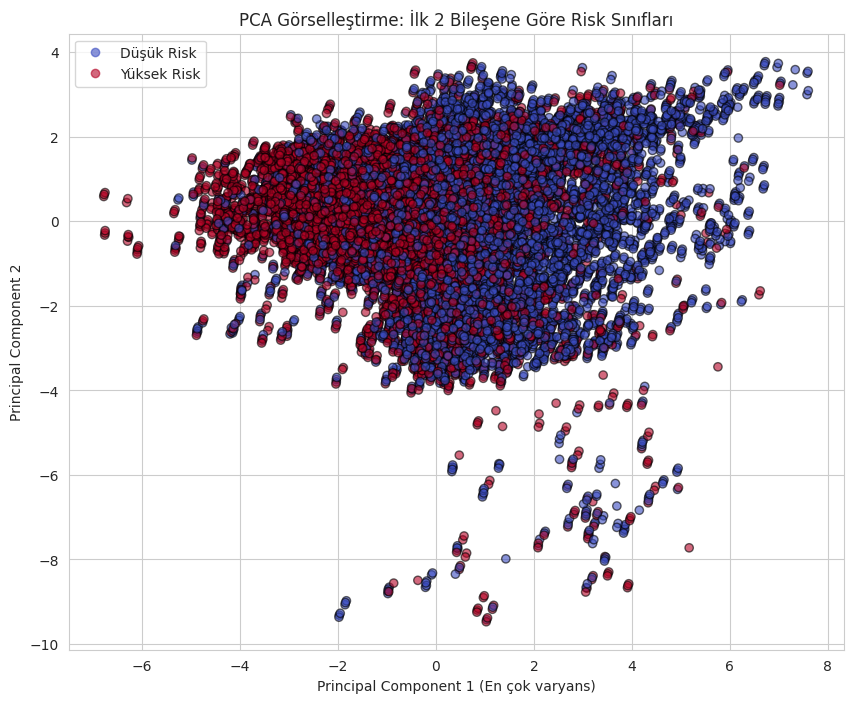

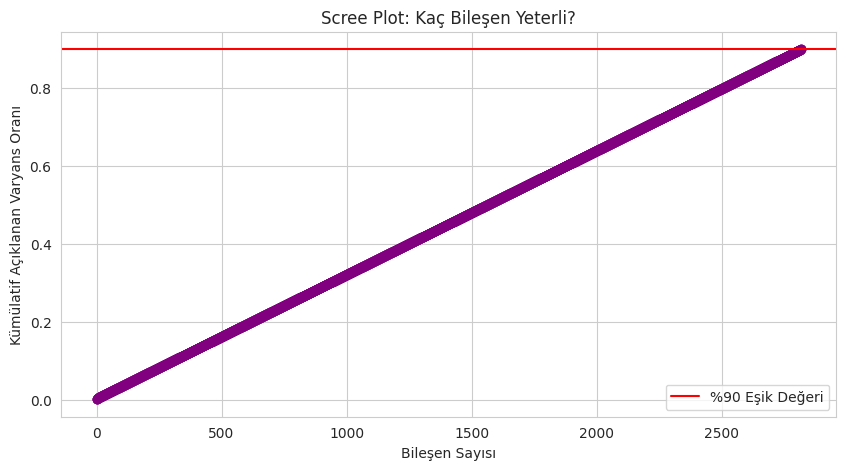

In [ ]:
print("\n--- PCA ANALİZİ ---")

#Algoritma, orijinal verideki bilginin (varyansın) %90'ını koruyacak minimum bileşen sayısını hesapladı.
#Yüzlerce özellik yerine, sadece gerekli olanları kullanarak modeli hızlandırdık.
pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Seçilen Bileşen Sayısı: {pca.n_components_}")
print(f"İndirgeme Oranı: {X_train.shape[1]} özellik -> {pca.n_components_} bileşen")

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_train, cmap='coolwarm', alpha=0.6, edgecolor='k')
plt.title('PCA Görselleştirme: İlk 2 Bileşene Göre Risk Sınıfları')
plt.xlabel('Principal Component 1 (En çok varyans)')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter.legend_elements()[0], labels=['Düşük Risk', 'Yüksek Risk'])
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='purple')
plt.axhline(y=0.90, color='r', linestyle='-', label='%90 Eşik Değeri')
plt.title('Scree Plot: Kaç Bileşen Yeterli?')
plt.xlabel('Bileşen Sayısı')
plt.ylabel('Kümülatif Açıklanan Varyans Oranı')
plt.legend()
plt.show()


In [ ]:
# Model Eğitim ve Karşılaştırma (Çok Sınıflı)
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import label_binarize

results = []

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, multi_class="auto"),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

datasets = [
    ("Tüm Özellikler (Scaled)", X_train_scaled, X_test_scaled),
    ("PCA İndirgenmiş", X_train_pca, X_test_pca)
]

classes = np.unique(y_train)

print("\n--- MODELLER EĞİTİLİYOR (MULTI-CLASS) ---")

for model_name, model in models.items():
    for data_name, Xtr, Xte in datasets:
        start = time.time()
        model.fit(Xtr, y_train)
        train_time = time.time() - start

        y_pred = model.predict(Xte)

        # Çok sınıflı metrikler (macro: her sınıf eşit ağırlık)
        acc = accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average="macro")
        prec_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
        rec_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)

        # ROC-AUC (One-vs-Rest)
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(Xte)  # [N, C]
            roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")
        else:
            roc_auc = np.nan

        results.append({
            "Model": model_name,
            "Veri Seti": data_name,
            "Accuracy": acc,
            "Precision (Macro)": prec_macro,
            "Recall (Macro)": rec_macro,
            "F1 Score (Macro)": f1_macro,
            "ROC AUC (OVR-Macro)": roc_auc,
            "Eğitim Süresi (sn)": train_time
        })

df_results = pd.DataFrame(results)
print("\n--- SONUÇ TABLOSU (Özet) ---")
display(df_results.sort_values(by=["ROC AUC (OVR-Macro)", "Recall (Macro)"], ascending=False))


--- MODELLER EĞİTİLİYOR ---

Sonuç Tablosu:
                 Model                Veri Seti  Accuracy  F1 Score   ROC AUC  \
0  Logistic Regression  Tüm Özellikler (Scaled)  0.882077  0.880869  0.937854   
1  Logistic Regression          PCA İndirgenmiş  0.784741  0.782834  0.860134   
2           k-NN (k=5)  Tüm Özellikler (Scaled)  0.697094  0.696956  0.758846   
3           k-NN (k=5)          PCA İndirgenmiş  0.700272  0.702524  0.755104   

   Süre (sn)  
0   4.304743  
1  22.658929  
2  24.723307  
3  23.661305  


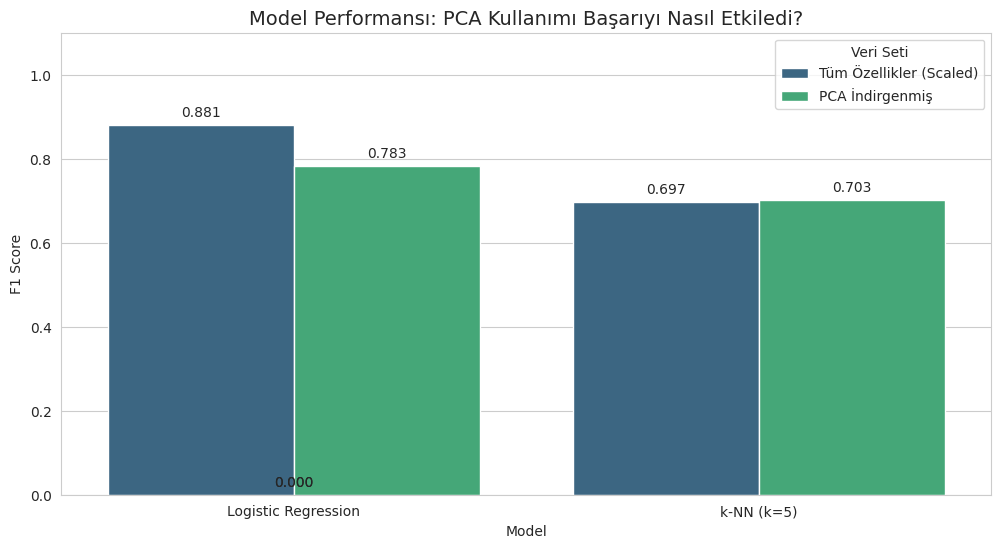

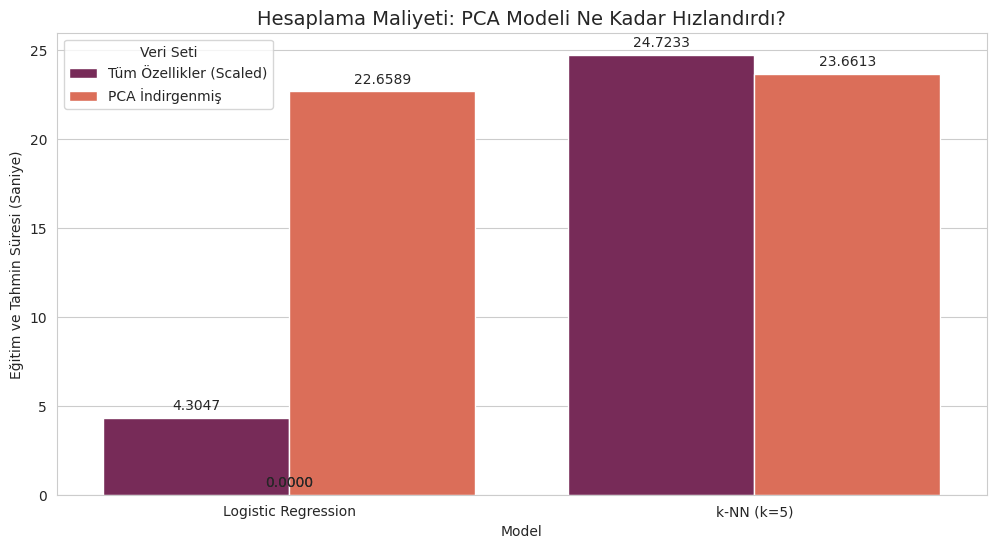

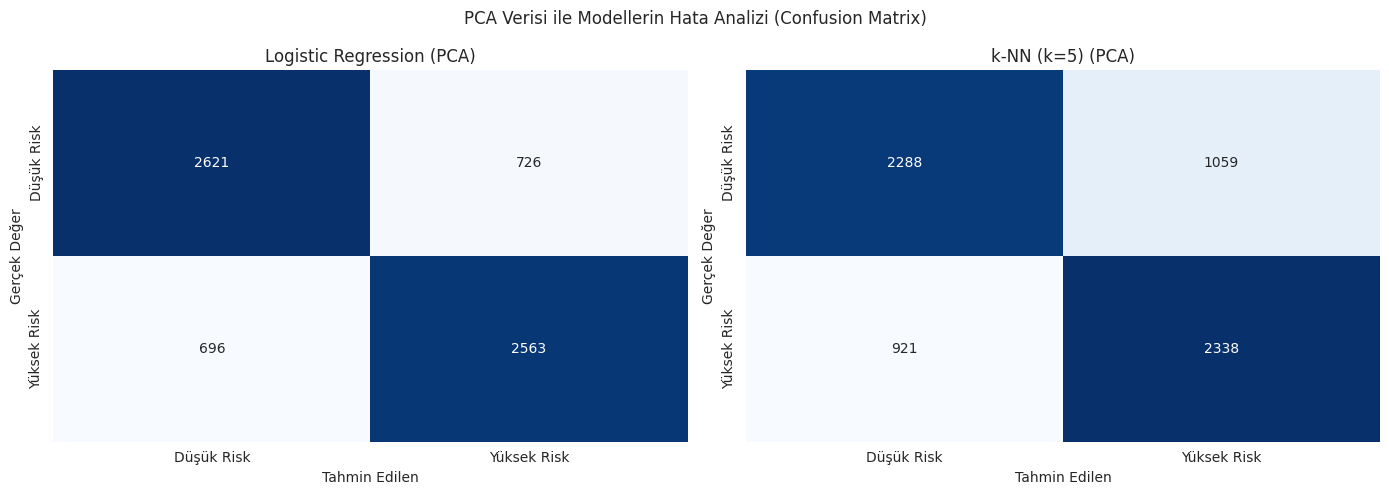

In [ ]:
#Sonuçların Görselleştirilmesi
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_results, x="Model", y="F1 Score", hue="Veri Seti", palette="viridis")
plt.title("Model Performansı: PCA Kullanımı Başarıyı Nasıl Etkiledi?", fontsize=14)
plt.ylim(0, 1.1)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')
plt.show()

plt.figure(figsize=(12, 6))
ax2 = sns.barplot(data=df_results, x="Model", y="Süre (sn)", hue="Veri Seti", palette="rocket")
plt.title("Hesaplama Maliyeti: PCA Modeli Ne Kadar Hızlandırdı?", fontsize=14)
plt.ylabel("Eğitim ve Tahmin Süresi (Saniye)")

for p in ax2.patches:
    ax2.annotate(format(p.get_height(), '.4f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')
plt.show()


# 5. CONFUSION MATRIX
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA Verisi ile Modellerin Hata Analizi (Confusion Matrix)')

for i, (model_name, model) in enumerate(models.items()):
    model.fit(X_train_pca, y_train)
    y_pred_pca = model.predict(X_test_pca)

    cm = confusion_matrix(y_test, y_pred_pca)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{model_name} (PCA)')
    axes[i].set_xlabel('Tahmin Edilen')
    axes[i].set_ylabel('Gerçek Değer')
    axes[i].set_xticklabels(['Düşük Risk', 'Yüksek Risk'])
    axes[i].set_yticklabels(['Düşük Risk', 'Yüksek Risk'])

plt.tight_layout()
plt.show()

Veriler PyTorch Tensor'una dönüştürüldü.
Girdi Boyutu (Input Size): 2819

Model Mimarisi:
SimpleNN(
  (layer1): Linear(in_features=2819, out_features=16, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (output_layer): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

--- EĞİTİM BAŞLIYOR ---
Epoch 10/50, Loss: 0.2499
Epoch 20/50, Loss: 0.1402
Epoch 30/50, Loss: 0.1263
Epoch 40/50, Loss: 0.1072
Epoch 50/50, Loss: 0.1009

--- MODEL 1 (SimpleNN) SONUÇLARI ---
Accuracy : 0.8246
F1 Score : 0.8162
ROC AUC  : 0.8930


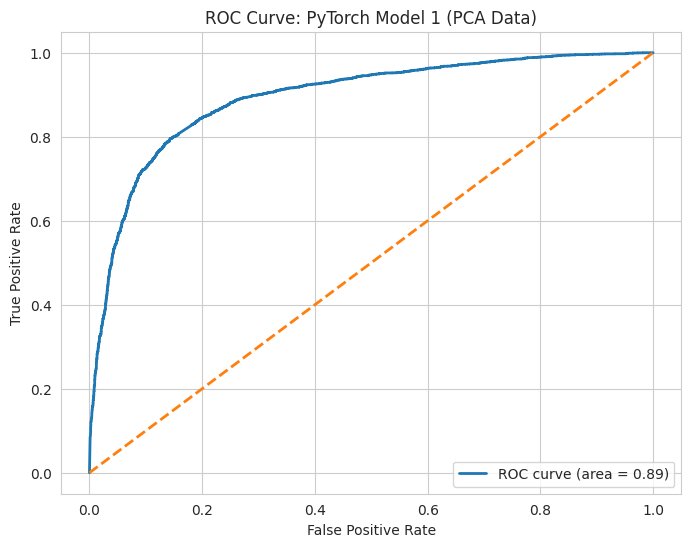

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# 1. VERİYİ PYTORCH FORMATINA ÇEVİRME (MULTI-CLASS)
# ---------------------------------------------------------
# X: float32, y: class index (long) -> CrossEntropyLoss bunu bekler.

X_train_tensor = torch.tensor(X_train_pca, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)  # [N]

X_test_tensor = torch.tensor(X_test_pca, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)    # [N]

print("Veriler PyTorch Tensor'una dönüştürüldü.")
print(f"Girdi Boyutu (Input Size): {X_train_tensor.shape[1]} (PCA bileşen sayısı)")
print(f"Sınıf Sayısı: {len(np.unique(y_train.values))} (0:Low, 1:Medium, 2:High)")

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 2. MODEL 1: SimpleNN (3 sınıf, logits)
# ---------------------------------------------------------
class SimpleNN(nn.Module):
    def __init__(self, input_dim, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, num_classes)  # logits
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train_pca.shape[1]
model = SimpleNN(input_dim, num_classes=3)
print("\nModel 1 (SimpleNN) Mimarisi:")
print(model)

# 3. EĞİTİM AYARLARI
# ---------------------------------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 50

print("\n--- MODEL 1 EĞİTİMİ BAŞLIYOR ---")
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_X)                 # [B, C]
        loss = criterion(logits, batch_y)       # batch_y: [B]
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")

# 4. DEĞERLENDİRME + MULTI-CLASS ROC-AUC
# ---------------------------------------------------------
model.eval()
with torch.no_grad():
    logits_test = model(X_test_tensor)                       # [N, C]
    prob_test = torch.softmax(logits_test, dim=1).cpu().numpy()  # [N, C]
    y_pred = np.argmax(prob_test, axis=1)

y_true = y_test.values

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro")
prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
roc_auc = roc_auc_score(y_true, prob_test, multi_class="ovr", average="macro")

print(f"\n--- MODEL 1 (SimpleNN) SONUÇLARI (MULTI-CLASS) ---")
print(f"Accuracy           : {acc:.4f}")
print(f"Precision (Macro)  : {prec_macro:.4f}")
print(f"Recall (Macro)     : {rec_macro:.4f}")
print(f"F1 Score (Macro)   : {f1_macro:.4f}")
print(f"ROC AUC (OVR-Macro): {roc_auc:.4f}")

# ROC Eğrisi (Her sınıf için One-vs-Rest)
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

plt.figure(figsize=(8, 6))
for i, name in enumerate(["Low", "Medium", "High"]):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], prob_test[:, i])
    auc_i = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc_i:.2f})')

plt.plot([0, 1], [0, 1], lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: PyTorch Model 1 (SimpleNN, PCA, OVR)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Eğitim kaybı
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Training Loss')
plt.title('Model 1 Eğitim Kayıp Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

Gelişmiş Model Mimarisi (AdvancedNN):
AdvancedNN(
  (net): Sequential(
    (0): Linear(in_features=2819, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

--- MODEL 2 EĞİTİMİ BAŞLIYOR ---
Epoch 20/100, Loss: 0.2411
Epoch 40/100, Loss: 0.1772
Epoch 60/100, Loss: 0.1435
Epoch 80/100, Loss: 0.1354
Epoch 100/100, Loss: 0.1246

--- MODEL 2 (AdvancedNN) SONUÇLARI ---
Accuracy  : 0.8513
Precision : 0.8613
Recall    : 0.8328
F1 Score  : 0.8468
ROC AUC   : 0.9085


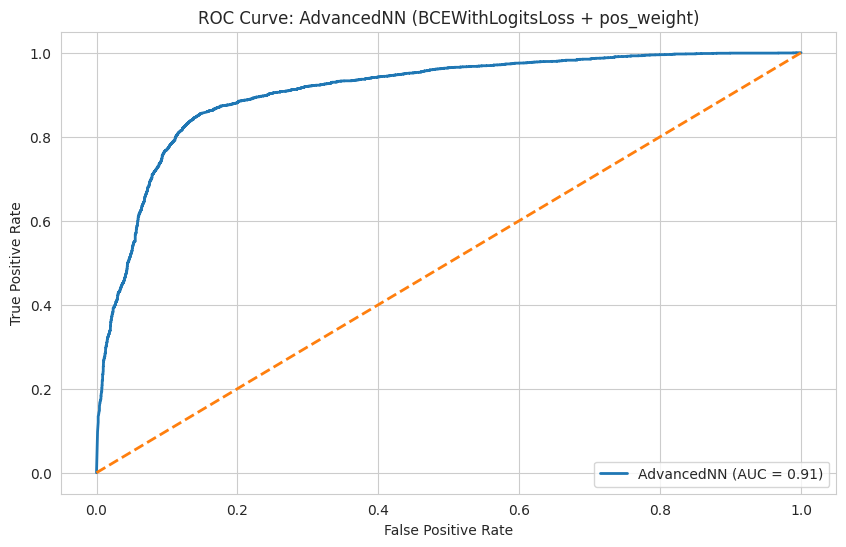

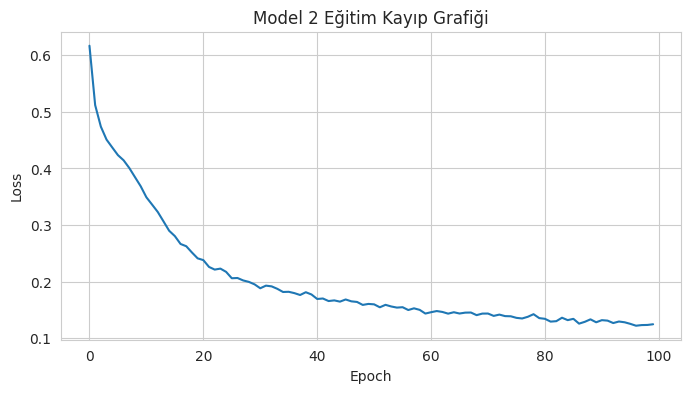

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.metrics import auc

# 1) MODEL 2 MİMARİSİ (GELİŞMİŞ SİNİR AĞI) - MULTI-CLASS LOGITS
# ---------------------------------------------------------
class AdvancedNN(nn.Module):
    def __init__(self, input_dim, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, num_classes)  # logits
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train_pca.shape[1]
model2 = AdvancedNN(input_dim, num_classes=3)
print("Model 2 (AdvancedNN) Mimarisi:")
print(model2)

# 2) EĞİTİM AYARLARI (Class Weight + CrossEntropyLoss)
# ---------------------------------------------------------
# Sınıf ağırlıkları: dengesizlik varsa FN riskini azaltmak için (opsiyonel)
class_counts = np.bincount(y_train.values, minlength=3)
class_weights = class_counts.sum() / np.maximum(class_counts, 1)
class_weights = class_weights / class_weights.sum() * 3  # normalize
weight_tensor = torch.tensor(class_weights, dtype=torch.float32)

criterion = nn.CrossEntropyLoss(weight=weight_tensor)
optimizer = optim.Adam(model2.parameters(), lr=0.001)

EPOCHS = 80
train_losses = []

print("\n--- MODEL 2 (AdvancedNN) EĞİTİMİ BAŞLIYOR ---")

for epoch in range(EPOCHS):
    model2.train()
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model2(batch_X)              # [B, C]
        loss = criterion(logits, batch_y)     # batch_y: [B]
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")

# 3) DEĞERLENDİRME (Softmax sadece burada)
# ---------------------------------------------------------
model2.eval()
with torch.no_grad():
    logits_test = model2(X_test_tensor)                       # [N, C]
    prob_test2 = torch.softmax(logits_test, dim=1).cpu().numpy()  # [N, C]
    y_pred2 = np.argmax(prob_test2, axis=1)

y_true = y_test.values

acc2 = accuracy_score(y_true, y_pred2)
f1_2 = f1_score(y_true, y_pred2, average="macro")
pre2 = precision_score(y_true, y_pred2, average="macro", zero_division=0)
rec2 = recall_score(y_true, y_pred2, average="macro", zero_division=0)
roc_auc2 = roc_auc_score(y_true, prob_test2, multi_class="ovr", average="macro")

print(f"\n--- MODEL 2 (AdvancedNN) SONUÇLARI (MULTI-CLASS) ---")
print(f"Accuracy           : {acc2:.4f}")
print(f"Precision (Macro)  : {pre2:.4f}")
print(f"Recall (Macro)     : {rec2:.4f}")
print(f"F1 Score (Macro)   : {f1_2:.4f}")
print(f"ROC AUC (OVR-Macro): {roc_auc2:.4f}")

# 4) ROC CURVE (OVR) - sınıf bazlı
# ---------------------------------------------------------
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

plt.figure(figsize=(10, 6))
for i, name in enumerate(["Low", "Medium", "High"]):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], prob_test2[:, i])
    auc_i = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc_i:.2f})')

plt.plot([0, 1], [0, 1], lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: AdvancedNN (PCA, OVR)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 5) EĞİTİM KAYIP GRAFİĞİ
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Training Loss')
plt.title('Model 2 Eğitim Kayıp Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()